In [1]:
import math
import logging
import time
from kan import *
from model import E3DensityModel, ResidualCorrectionModel
from torch.utils.data.dataloader import DataLoader
import torch
import glob
import os
import numpy as np
from tqdm import  tqdm
from torch.utils.data import DataLoader, random_split, Subset
# from torch.utils.data import DataLoader
from ase.db import connect
from utils_see_chg import DensityData, MyCollator
from transformers import AdamW, get_scheduler

random_seed = 42
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)


device = 'cuda:7'

pts_model = E3DensityModel()
bas_model  = E3DensityModel()
res_model  = ResidualCorrectionModel(num_embeddings=300, embedding_dim=128)


# mysql_url= 'mysql://root:@localhost:3306/temp_chg'
mysql_url = '/data/chg/quick.db'
dataset = DensityData(mysql_url)
total_count = len(dataset)
print(f"Total count: {total_count}")
train_count = int(0.8 * total_count)
valid_count = int(0.1 * total_count)
test_count = total_count - train_count - valid_count
train_dataset, valid_dataset, test_dataset = random_split(dataset, [train_count, valid_count, test_count])
checkpoint_pts = torch.load('/data/chg/charge3net-main-suth/checkpoints_suth/zno_ploy_pt.pt', map_location='cpu')
pts_model.load_state_dict(checkpoint_pts)
pts_model = pts_model.to(device)

/home/cb/anaconda3/envs/mace/lib/python3.9/site-packages/torch/jit/_check.py:181: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn("The TorchScript type system doesn't support "


checkpoint directory created: ./model
saving model version 0.0
len db 900
Total count: 900


In [3]:
#res_model

In [2]:
all_true = []
all_pred = []
all_true_corr = []
all_pred_corr = []
countt = 0
valid_dataset = test_dataset

val_dataloader = DataLoader(
        #[valid_dataset],
        valid_dataset,
        batch_size=4,
        num_workers=0,
        shuffle=True,
        collate_fn=MyCollator(mysql_url, cutoff=4, num_probes=300))

flag = 0
with torch.no_grad():
    res_model.train()
    for step, (big_batch, big_batch_invalid) in enumerate(val_dataloader):
        for batch in tqdm(big_batch, total=len(big_batch)):
            batch = {k: v.to(device) for k, v in batch.items()}
            output_old, _ = pts_model(batch)
            output_old = output_old.view(-1)
            all_pred.append(output_old.detach().cpu())
            tru = batch['probe_target'].view(-1)
            all_true.append(tru.detach().cpu())
        for batch in tqdm(big_batch_invalid, total=len(big_batch_invalid)):


            batch = {k: v.to(device) for k, v in batch.items()}
            output, _ = pts_model(batch)
            output = output.view(-1)
            all_pred.append(output.detach().cpu())
            tru = batch['probe_target'].view(-1)
            all_true.append(tru.detach().cpu())

        #     batch = {k: v.to(device) for k, v in batch.items()}
        #     output_old, _ = pts_model(batch)
        #     output_old = output_old.view(-1)
        #     output, node_rep = bas_model(batch)
        #     output = output.view(-1)
        #     res, _ = res_model(batch, node_rep)
        #     tru = batch['probe_target'].view(-1)
        #     all_true.append(tru.detach().cpu())
        #     all_pred.append(output_old.detach().cpu())
        #     all_pred_corr.append(output.detach().cpu() + 1.0 * res.view(-1).detach().cpu())
        # print(len(all_pred_corr))
        flag += 1
        if flag >0:
            break

100%|██████████| 80/80 [00:24<00:00,  3.27it/s]


In [3]:
from sklearn.metrics import r2_score, mean_absolute_error
all_true = torch.cat(all_true, dim=0).numpy()
all_pred = torch.cat(all_pred, dim=0).numpy()

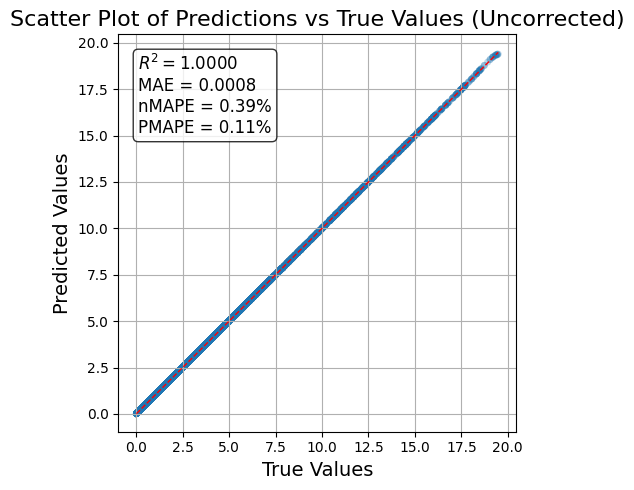

In [4]:
# %config InlineBackend.figure_format = 'svg'
all_true_avg,all_pred_avg,all_pred_corr_avg = all_true,all_pred, all_pred_corr
import matplotlib.pyplot as plt
def nmape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
def nmape_batch(y_true, y_pred):
    # Convert to tensors if inputs are numpy arrays
    y_true_tensor = torch.tensor(y_true, dtype=torch.float32)
    y_pred_tensor = torch.tensor(y_pred, dtype=torch.float32)

    # Calculate the batch-level nMAPE
    diff = torch.abs(y_true_tensor - y_pred_tensor)  
    target_sum = torch.abs(y_true_tensor).sum()  # Sum over the entire vector, no dim argument needed
    nmape_per_batch = diff.sum() / target_sum * 100  
    return nmape_per_batch.mean() 


r2 = r2_score(all_true_avg, all_pred_avg)
mae = mean_absolute_error(all_true_avg, all_pred_avg)
nmape_value = nmape(all_true_avg, all_pred_avg)
pmape = nmape_batch(all_true_avg, all_pred_avg)
# r2_corr = r2_score(all_true_avg, all_pred_corr_avg)
# mae_corr = mean_absolute_error(all_true_avg, all_pred_corr_avg)
# nmape_corr_value = nmape(all_true_avg, all_pred_corr_avg)


# 创建一个单独的子图
fig, ax = plt.subplots(figsize=(5, 5))

# 绘制散点图
ax.scatter(all_true_avg, all_pred_avg, alpha=0.1, s=25, edgecolors='none')

# 绘制 y=x 的对角线
ax.plot([all_true_avg.min(), all_true_avg.max()], [all_true_avg.min(), all_true_avg.max()], 'r--', lw=1)

# 添加统计信息文本框
ax.text(
    0.05, 0.95, 
    f"$R^2 = {r2:.4f}$\nMAE = {mae:.4f}\nnMAPE = {nmape_value:.2f}%\nPMAPE = {pmape:.2f}%",
    transform=ax.transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)


# 设置轴标签和标题
ax.set_xlabel('True Values', fontsize=14)
ax.set_ylabel('Predicted Values', fontsize=14)
ax.set_title('Scatter Plot of Predictions vs True Values (Uncorrected)', fontsize=16)
ax.grid(True)

# 调整布局并显示图像
plt.tight_layout()
# plt.savefig('scatter_plot_with_nmape.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
all_true = []
all_pred = []
all_true_corr = []
all_pred_corr = []
countt = 0
valid_dataset = train_dataset

val_dataloader = DataLoader(
        #[valid_dataset],
        valid_dataset,
        batch_size=1,
        num_workers=0,
        shuffle=True,
        collate_fn=MyCollator(mysql_url, cutoff=4, num_probes=300))

flag = 0
with torch.no_grad():
    for step, (big_batch, big_batch_invalid) in enumerate(val_dataloader):
        for batch in tqdm(big_batch, total=len(big_batch)):
            batch = {k: v.to(device) for k, v in batch.items()}
            output_old, _ = base_model(batch)
            output_old = output_old.view(-1)
            output, node_rep = new_model(batch)
            output = output.view(-1)
            res, _ = res_model(batch, node_rep)
            tru = batch['probe_target'].view(-1)
            all_true.append(tru.detach().cpu())
            all_pred.append(output_old.detach().cpu())
            #all_pred_corr.append(output.detach().cpu() + 1.0 * res.view(-1).detach().cpu())
            all_pred_corr.append(res.view(-1).detach().cpu())
        print(len(all_pred_corr))
  
        for batch in tqdm(big_batch_invalid, total=len(big_batch_invalid)):
            batch = {k: v.to(device) for k, v in batch.items()}
            output, _ = base_model(batch)
            output = output.view(-1)
            tru = batch['probe_target'].view(-1)
            all_true.append(tru.detach().cpu())
            all_pred.append(output.detach().cpu())
            all_pred_corr.append(output.detach().cpu())
        flag += 1
        if flag >0:
            break

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
all_true = torch.cat(all_true, dim=0).numpy()
all_pred = torch.cat(all_pred, dim=0).numpy()
# all_true_corr = torch.cat(all_true_corr, dim=0).numpy()
all_pred_corr = torch.cat(all_pred_corr, dim=0).numpy()
print(all_pred_corr.shape)
all_true_avg,all_pred_avg,all_pred_corr_avg = all_true,all_pred, all_pred_corr
import matplotlib.pyplot as plt
def nmape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


r2 = r2_score(all_true_avg, all_pred_avg)
mae = mean_absolute_error(all_true_avg, all_pred_avg)
r2_corr = r2_score(all_true_avg, all_pred_corr_avg)
mae_corr = mean_absolute_error(all_true_avg, all_pred_corr_avg)
nmape_value = nmape(all_true_avg, all_pred_avg)
nmape_corr_value = nmape(all_true_avg, all_pred_corr_avg)


fig, axs = plt.subplots(1, 2, figsize=(16, 8))
# 子图1：未校正预测
axs[0].scatter(all_true_avg, all_pred_avg, alpha=0.5, s=25, edgecolors='none')
axs[0].plot([all_true_avg.min(), all_true_avg.max()], [all_true_avg.min(), all_true_avg.max()], 'r--', lw=1)
axs[0].text(
    0.05, 0.95, 
    f"$R^2 = {r2:.4f}$\nMAE = {mae:.4f}\nnMAPE = {nmape_value:.2f}%", 
    transform=axs[0].transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
axs[0].set_xlabel('True Values', fontsize=14)
axs[0].set_ylabel('Predicted Values', fontsize=14)
axs[0].set_title('Scatter Plot of Predictions vs True Values (Uncorrected)', fontsize=16)
axs[0].grid(True)

# 子图2：校正后预测
axs[1].scatter(all_true_avg, all_pred_corr_avg, alpha=0.5, s=25, edgecolors='none')
axs[1].plot([all_true_avg.min(), all_true_avg.max()], [all_true_avg.min(), all_true_avg.max()], 'r--', lw=1)
axs[1].text(
    0.05, 0.95, 
    f"$R^2 = {r2_corr:.4f}$\nMAE = {mae_corr:.4f}\nnMAPE = {nmape_corr_value:.2f}%", 
    transform=axs[1].transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
axs[1].set_xlabel('True Values', fontsize=14)
axs[1].set_ylabel('Predicted Values', fontsize=14)
axs[1].set_title('Scatter Plot of Predictions vs True Values (Corrected)', fontsize=16)
axs[1].grid(True)

# 调整布局并保存图像
plt.tight_layout()
plt.savefig('scatter_GLOB_plots_with_nmape.png', dpi=300, bbox_inches='tight')
plt.show()